In [1]:
import sys
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../")
from simulators.CA_modified import CellularAutomaton_humidity_age

Parameters : alpha, beta, gamme are the parameters that we want to find

In [2]:
H, W = 100, 100
N_FIRES = 20
N_STEPS = 20
SAVE_EVERY = 5

alpha = 2.0   # age
beta = 2.0    # moisture
gamma = 1.2   # slope

SEED = 42
rng = np.random.default_rng(SEED)

OUT_DIR = Path("synthetic_fire_dataset")
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / "fires").mkdir(exist_ok=True)

Utilitary function

In [3]:
def normalize(x):
    """ Normalize a 2D array to [0, 1]."""
    x = x.astype(float)
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

def smooth2d(x, n=4):
    """ Apply a  3x3 mean filter n times to smooth a 2D array."""
    for _ in range(n):
        p = np.pad(x, 1, mode="reflect")
        x = (
            p[:-2, :-2] + 2*p[:-2, 1:-1] + p[:-2, 2:] +
            2*p[1:-1, :-2] + 4*p[1:-1, 1:-1] + 2*p[1:-1, 2:] +
            p[2:, :-2] + 2*p[2:, 1:-1] + p[2:, 2:]
        ) / 16.0
    return x

def coarse_noise(shape, coarse=(12, 12), smooth_passes=4, rng=None):
    """Generates a smooth low-frequency 2D random field by upsampling coarse Gaussian noise and then smoothing and normalizing it."""
    rng = np.random.default_rng() if rng is None else rng
    base = rng.normal(size=coarse)
    ry = int(np.ceil(shape[0] / coarse[0]))
    rx = int(np.ceil(shape[1] / coarse[1]))
    up = np.kron(base, np.ones((ry, rx)))[:shape[0], :shape[1]]
    return normalize(smooth2d(up, n=smooth_passes))

def sample_random_ignition_point(H, W, rng):
    i0 = int(rng.integers(0, H))
    j0 = int(rng.integers(0, W))
    return i0, j0

Create realistic maps

In [4]:
def make_fixed_maps(H, W, rng):
    y = np.linspace(-1, 1, H)
    x = np.linspace(-1, 1, W)
    Y, X = np.meshgrid(y, x, indexing="ij")

    # Different components of the height map : homogeneous slope + mountain + basin + random hills
    slope = 0.35 * (0.8 * X + 0.3 * Y)
    mountain = 1.2 * np.exp(-((X - 0.35)**2 / 0.10**2 + (Y + 0.20)**2 / 0.18**2))
    basin = -0.9 * np.exp(-((X + 0.30)**2 / 0.20**2 + (Y - 0.25)**2 / 0.12**2))
    hills = 0.6 * (2 * coarse_noise((H, W), coarse=(10, 10), smooth_passes=5, rng=rng) - 1)

    height_grid = normalize(smooth2d(slope + mountain + basin + hills, n=3))

    # Age map : correlated with height (older on mountains) + some random variation
    age_grid = normalize(
        0.6 * coarse_noise((H, W), coarse=(10, 10), smooth_passes=4, rng=rng)
        + 0.4 * height_grid
    )
    age_grid = 1 + 79 * age_grid  # age between 1 and 80

    # Humidity map : inversely correlated with height + some random variation
    moisture_grid = normalize(
        0.55 * (1 - height_grid)
        + 0.45 * coarse_noise((H, W), coarse=(14, 14), smooth_passes=4, rng=rng)
    )

    return (
        height_grid.astype(np.float32),
        age_grid.astype(np.float32),
        moisture_grid.astype(np.float32),
    )

height_grid, age_grid, moisture_grid = make_fixed_maps(H, W, rng)

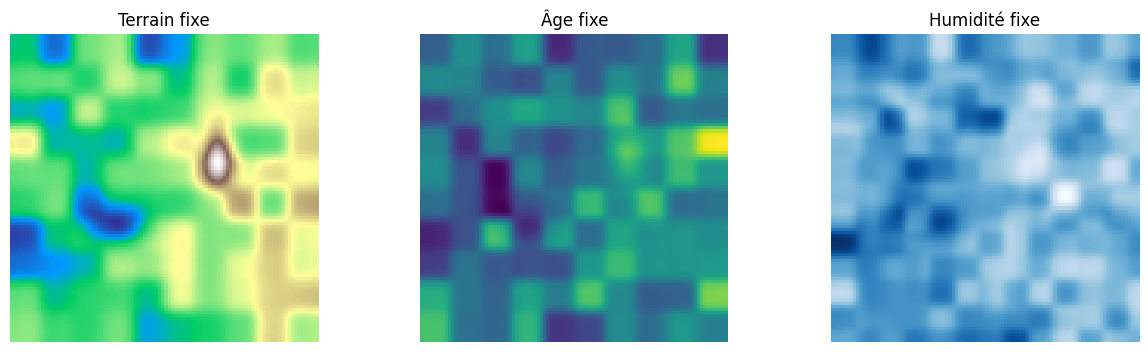

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].imshow(height_grid, cmap="terrain")
axs[0].set_title("Terrain fixe")

axs[1].imshow(age_grid, cmap="viridis")
axs[1].set_title("Âge fixe")

axs[2].imshow(moisture_grid, cmap="Blues")
axs[2].set_title("Humidité fixe")

for ax in axs:
    ax.axis("off")

plt.show()

In [6]:
def make_wind_grid(H, W, rng):
    """ Create a smooth, spatially coherent wind speed map with values between 0.4 and 1.2. """
    # Wind speed map : smooth, spatially coherent
    base = rng.uniform(0.4, 1.2)
    spatial = coarse_noise((H, W), coarse=(12, 12), smooth_passes=5, rng=rng)
    wind_grid = base * (0.6 + 0.8 * spatial)
    return wind_grid.astype(np.float32)

Functions used to modelize the slope and the moisture : we will want to find the beta and the gamma

In [7]:
def make_phi(gamma):
    """ Create a function phi(delta_h) that models how height difference affects fire spread probability. """
    def phi(delta_h):
        # delta_h > 0 : fire spreads uphill, but with diminishing returns (sqrt)
        if delta_h <= 0:
            return np.exp(gamma * delta_h)
        else:
            return 1.0 + gamma * np.sqrt(delta_h)
    return phi

def make_psi(beta):
    """ Create a function psi(m) that models how moisture affects fire spread probability. """
    def psi(m):
        return np.exp(-beta * m)
    return psi

In [8]:
def simulate_one_fire(
    height_grid,
    age_grid,
    moisture_grid,
    alpha,
    beta,
    gamma,
    n_steps=150,
    save_every=5,
    ignition_point=None,
    rng=None,
):
    rng = np.random.default_rng() if rng is None else rng
    H, W = height_grid.shape

    wind_grid = make_wind_grid(H, W, rng)
    phi = make_phi(gamma)
    psi = make_psi(beta)

    ca = CellularAutomaton_humidity_age(
        grid_height=H,
        grid_width=W,
        wind_grid=wind_grid,
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        phi=phi,
        psi=psi,
        alpha_age=alpha,
    )

    if ignition_point is None:
        i0, j0 = sample_random_ignition_point(H, W, rng)
    else:
        i0, j0 = ignition_point

    ca.initialize_ignition([(i0, j0)], [0.8])

    snapshots = []
    saved_steps = []

    arrival_time = -np.ones((H, W), dtype=np.int16)
    state0 = ca.get_state().copy()
    arrival_time[state0 >= 0.5] = 0

    for step in range(n_steps + 1):
        state = ca.get_state().copy()

        if step % save_every == 0 or step == n_steps:
            snapshots.append((255 * state).astype(np.uint8))
            saved_steps.append(step)

        if step == n_steps:
            break

        ca.evolve(use_age=True, use_moisture=True)

        new_state = ca.get_state().copy()
        new_cells = (new_state >= 0.5) & (arrival_time < 0)
        arrival_time[new_cells] = step + 1

    final_state = (255 * ca.get_state()).astype(np.uint8)

    return {
        "wind_grid": wind_grid,
        "ignition_point": np.array([i0, j0], dtype=np.int16),
        "saved_steps": np.array(saved_steps, dtype=np.int16),
        "snapshots": np.stack(snapshots),
        "final_state": final_state,
        "arrival_time": arrival_time,
        "burned_fraction": float(np.mean(ca.get_state() >= 0.5)),
    }

We run one example

Text(0.5, 1.0, 'Final')

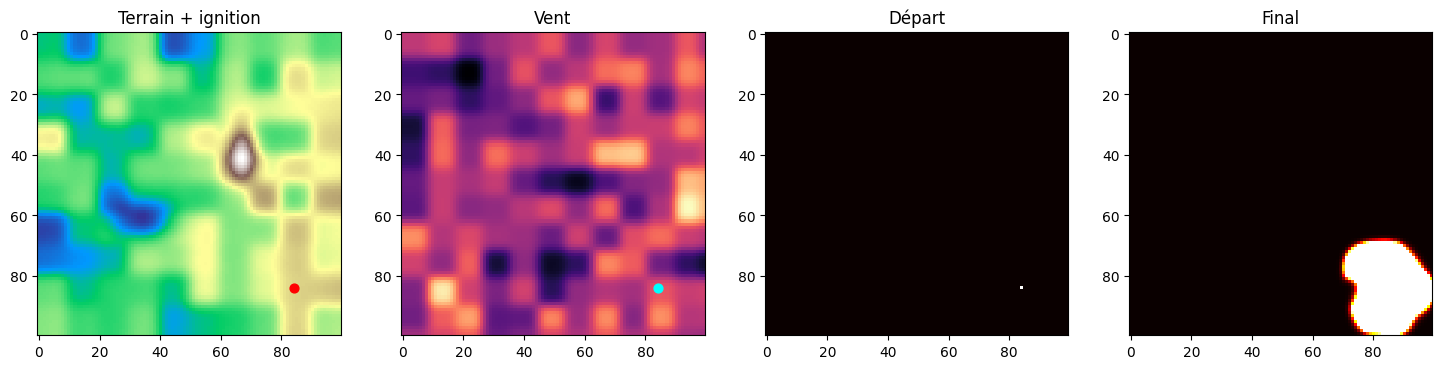

In [9]:
example = simulate_one_fire(
    height_grid=height_grid,
    age_grid=age_grid,
    moisture_grid=moisture_grid,
    alpha=alpha,
    beta=beta,
    gamma=gamma,
    n_steps=N_STEPS,
    save_every=SAVE_EVERY,
    rng=rng,
)

i0, j0 = example["ignition_point"]

fig, axs = plt.subplots(1, 4, figsize=(18, 4))

axs[0].imshow(height_grid, cmap="terrain")
axs[0].scatter([j0], [i0], c="red", s=40)
axs[0].set_title("Terrain + ignition")

axs[1].imshow(example["wind_grid"], cmap="magma")
axs[1].scatter([j0], [i0], c="cyan", s=40)
axs[1].set_title("Vent")

axs[2].imshow(example["snapshots"][0], cmap="hot")
axs[2].set_title("Départ")

axs[3].imshow(example["final_state"], cmap="hot")
axs[3].set_title("Final")



To save the simulations

In [10]:
np.savez_compressed(
    OUT_DIR / "common_maps.npz",
    height_grid=height_grid,
    age_grid=age_grid,
    moisture_grid=moisture_grid,
)

config = {
    "H": H,
    "W": W,
    "N_FIRES": N_FIRES,
    "N_STEPS": N_STEPS,
    "SAVE_EVERY": SAVE_EVERY,
    "alpha": alpha,
    "beta": beta,
    "gamma": gamma,
    "seed": SEED,
    "automaton_class": "CellularAutomaton_humidity_age",
}

with open(OUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

In [11]:
index = []

for fire_id in range(N_FIRES):
    sim = simulate_one_fire(
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        n_steps=N_STEPS,
        save_every=SAVE_EVERY,
        rng=rng,
    )

    file_path = OUT_DIR / "fires" / f"fire_{fire_id:04d}.npz"

    np.savez_compressed(
    file_path,
    wind_grid=sim["wind_grid"],
    ignition_point=sim["ignition_point"],
    saved_steps=sim["saved_steps"],
    snapshots=sim["snapshots"],
    final_state=sim["final_state"],
    arrival_time=sim["arrival_time"],
    burned_fraction=np.float32(sim["burned_fraction"]),
)

    index.append({
        "fire_id": fire_id,
        "file": str(file_path.relative_to(OUT_DIR)),
        "ignition_point": sim["ignition_point"].tolist(),
        "burned_fraction": sim["burned_fraction"],
    })

    if (fire_id + 1) % 50 == 0:
        print(f"{fire_id + 1}/{N_FIRES} feux générés")

In [12]:
with open(OUT_DIR / "dataset_index.json", "w", encoding="utf-8") as f:
    json.dump(index, f, indent=2)

print("Dataset saved in :", OUT_DIR.resolve())

Dataset saved in : C:\Users\leala\Documents\interactions\interactions\notebooks\synthetic_fire_dataset


In [13]:
fire_path = Path("synthetic_fire_dataset/fires/fire_0000.npz")
fire = np.load(fire_path)

In [14]:
print(fire.files)

['wind_grid', 'ignition_point', 'saved_steps', 'snapshots', 'final_state', 'arrival_time', 'burned_fraction']


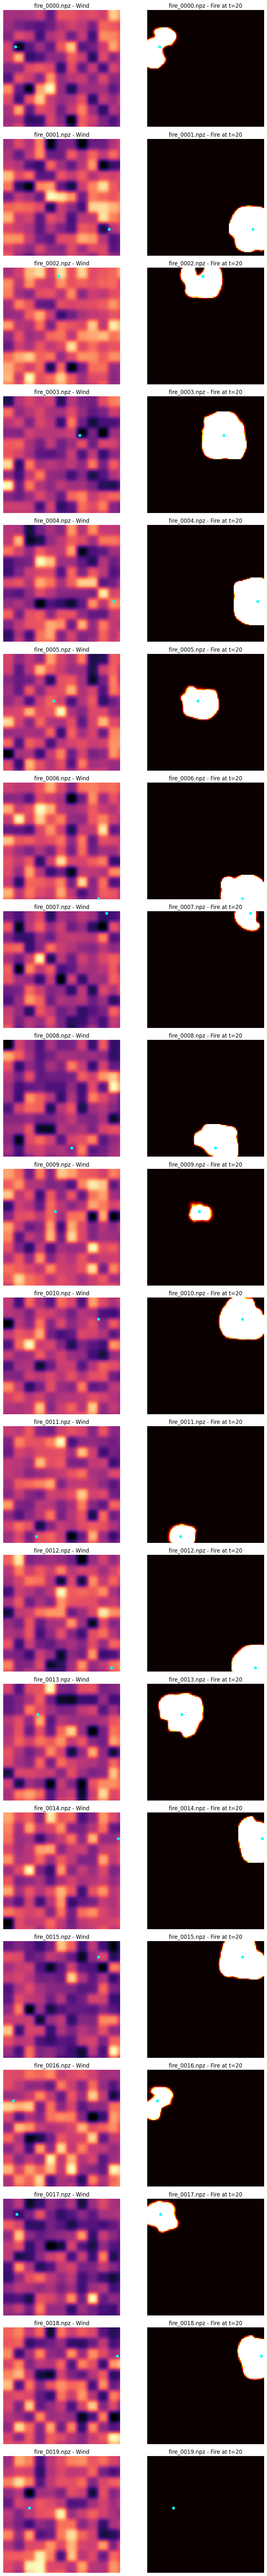

In [16]:
with open(OUT_DIR / "dataset_index.json", "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

fire_paths = [OUT_DIR / item["file"] for item in dataset_index]

fig, axs = plt.subplots(len(fire_paths), 2, figsize=(10, 4 * len(fire_paths)))

if len(fire_paths) == 1:
    axs = np.expand_dims(axs, axis=0)

for r, fire_path in enumerate(fire_paths):
    fire = np.load(fire_path)

    wind_grid = fire["wind_grid"].astype(np.float32)
    final_state = fire["final_state"].astype(np.float32) / 255.0
    ignition_point = fire["ignition_point"].astype(int)

    i0, j0 = ignition_point

    axs[r, 0].imshow(wind_grid, cmap="magma")
    axs[r, 0].scatter([j0], [i0], c="cyan", s=30)
    axs[r, 0].set_title(f"{fire_path.name} - Wind")
    axs[r, 0].axis("off")

    axs[r, 1].imshow(final_state, cmap="hot")
    axs[r, 1].scatter([j0], [i0], c="cyan", s=30)
    axs[r, 1].set_title(f"{fire_path.name} - Fire at t=20")
    axs[r, 1].axis("off")

plt.tight_layout()
plt.show()